# Image processing

**Duration** ~50 min &nbsp;·&nbsp; **Session** Day 1, Python notebooks

Last notebook ended badly on purpose. We thresholded the nuclei, counted **34**
objects, and the expert annotation said **39**. This notebook is about closing
that gap, and about the general habit it stands for: *almost no image is ready
to be thresholded as it comes off the microscope.*

**This notebook covers**

- recognising uneven illumination, and correcting it
- choosing between a Gaussian and a median filter, and the reason for each
- using morphological operations to clean up a binary image
- separating touching objects with a watershed
- the difference between semantic and instance segmentation

**Data**: `data/bbbc020/` field `2h_1` (the nuclei from last notebook) and
`data/misc/rice.png`.

## 1. Why did we get 34 instead of 39?

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.color import label2rgb

from course import DATA, show

nuclei = tifffile.imread(DATA / "bbbc020" / "images" / "2h_1_nuclei.tif")
truth = tifffile.imread(DATA / "bbbc020" / "gt" / "2h_1_nuclei_labels.tif")

naive = label(nuclei > threshold_otsu(nuclei))
print("naive threshold:", naive.max(), "objects |  truth:", truth.max())

naive threshold: 34 objects |  truth: 39


In [2]:
# How big is each object we found? Sort the areas and look at the small end.
areas = np.sort([(naive == i).sum() for i in range(1, naive.max() + 1)])
print("ten smallest object areas:", areas[:10])
print("ten largest object areas :", areas[-10:])

ten smallest object areas: [236 304 372 465 515 517 518 532 535 543]
ten largest object areas : [1100 1217 1261 1348 1365 1397 1425 1467 1597 2019]


Read the two ends of that list against each other.

A typical nucleus in the expert annotation covers about 560 pixels. The
*smallest* thing the threshold found is 236 px: small, but a plausible nucleus,
not a speck of noise. So **this image does not have a speck problem**, and
running a size filter over it would achieve nothing except deleting real nuclei.

The large end is where the trouble is. The biggest "object" is over 2000 px,
three times the typical nucleus. That is not one nucleus; that is two or three
nuclei touching, thresholded into a single connected region and given a single
label. Every one of those costs a nucleus from the count, which is why the total
came out **below** the truth.

```{tip}
Inspecting the size distribution before reaching for a filter takes ten seconds
and shows which problem is actually present. Applying a cleanup step without
justifying it is how data gets deleted and called preprocessing.
```

## 2. Uneven illumination

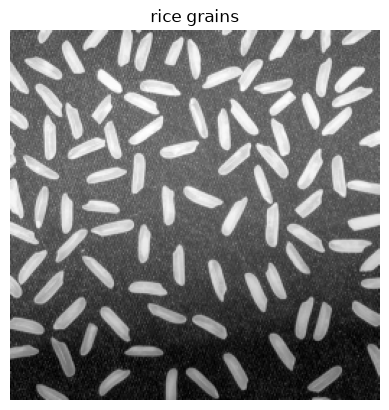

mean intensity, top third   : 131.9
mean intensity, bottom third: 80.8


In [3]:
from imageio.v3 import imread

rice = imread(DATA / "misc" / "rice.png")

show(rice, title="rice grains")
plt.show()

# Is the lighting even? Compare the top of the image with the bottom.
third = rice.shape[0] // 3
print(f"mean intensity, top third   : {rice[:third].mean():.1f}")
print(f"mean intensity, bottom third: {rice[-third:].mean():.1f}")

The top of the image is much brighter than the bottom, not because the grains
differ, but because the illumination does. This is extremely common: uneven
lamps, vignetting, an angled sample.

It breaks global thresholding completely, because **one threshold cannot be
right everywhere at once**.

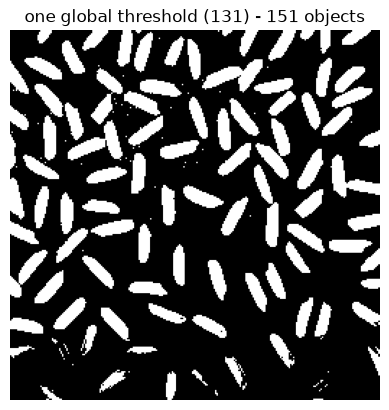

In [4]:
t = threshold_otsu(rice)
naive_rice = label(rice > t)

show(rice > t, title=f"one global threshold ({t}) - {naive_rice.max()} objects")
plt.show()

Look at the bottom of that mask: whole grains are missing, because down there
even a grain is darker than the threshold. Meanwhile the bright top has merged
background into the foreground. The count, **151**, is nonsense; the image has
somewhere around 95–100 grains.

### Estimating the background and removing it

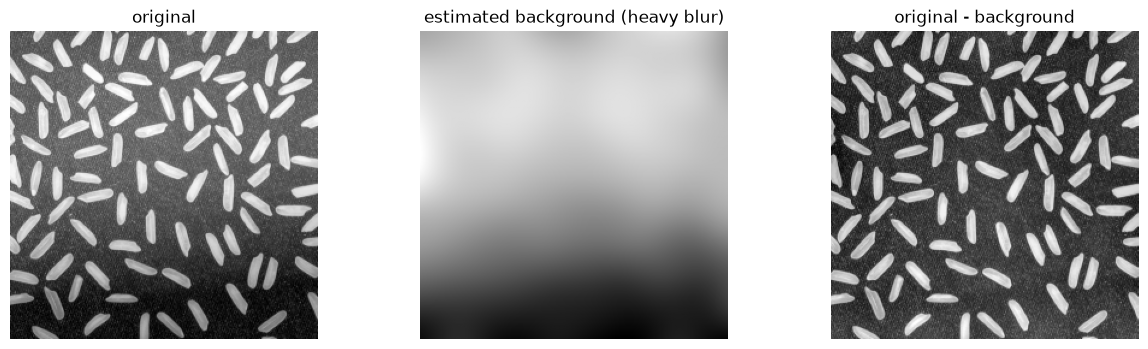

In [5]:
from skimage.filters import gaussian

# Blur the image so heavily that the grains vanish and only the lighting is left.
background = gaussian(rice, sigma=20, preserve_range=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
show(rice, title="original", ax=axes[0])
show(background, title="estimated background (heavy blur)", ax=axes[1])
show(rice - background, title="original - background", ax=axes[2])
plt.show()

That is the whole idea of background subtraction: blur away everything of
interest, keep what is left as an estimate of the illumination, and subtract
it.

`skimage` has a purpose-built version of this called a **white top-hat**, which
keeps only features smaller than a given size. It is what Fiji's
`Process ▸ Subtract Background…` (rolling ball) is doing.

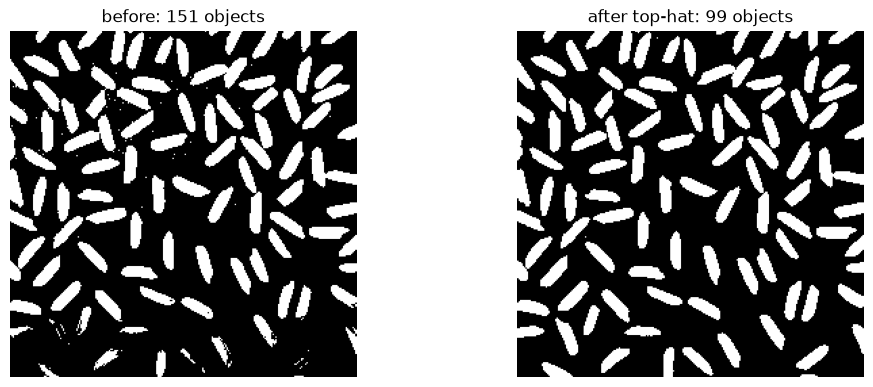

before: 151  after: 99  (expected ~95-100)


In [6]:
from skimage.morphology import white_tophat, disk

# disk(12) must be comfortably LARGER than a grain and smaller than the
# illumination pattern - that is the only tuning this needs.
corrected = white_tophat(rice, disk(12))

t2 = threshold_otsu(corrected)
fixed = label(corrected > t2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
show(rice > t, title=f"before: {naive_rice.max()} objects", ax=axes[0])
show(corrected > t2, title=f"after top-hat: {fixed.max()} objects", ax=axes[1])
plt.show()

print("before:", naive_rice.max(), " after:", fixed.max(), " (expected ~95-100)")

From 151 to 99, by fixing the image rather than fiddling with the threshold.

**This is the single most valuable habit in this notebook.** When a segmentation
is bad, the instinct is to hunt for a better threshold. Usually the threshold is
not the problem.

## 3. Denoising: Gaussian vs median

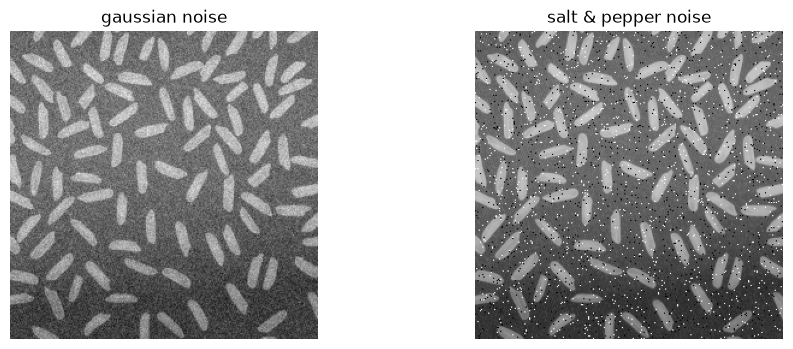

In [7]:
rng = np.random.default_rng(0)

# Two different kinds of noise, to make the point that the fix differs.
grainy = rice.astype(float) + rng.normal(0, 15, rice.shape)

speckled = rice.copy()
spots = rng.random(rice.shape)
speckled[spots < 0.02] = 0      # pepper
speckled[spots > 0.98] = 255    # salt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
show(grainy, title="gaussian noise", ax=axes[0])
show(speckled, title="salt & pepper noise", ax=axes[1])
plt.show()

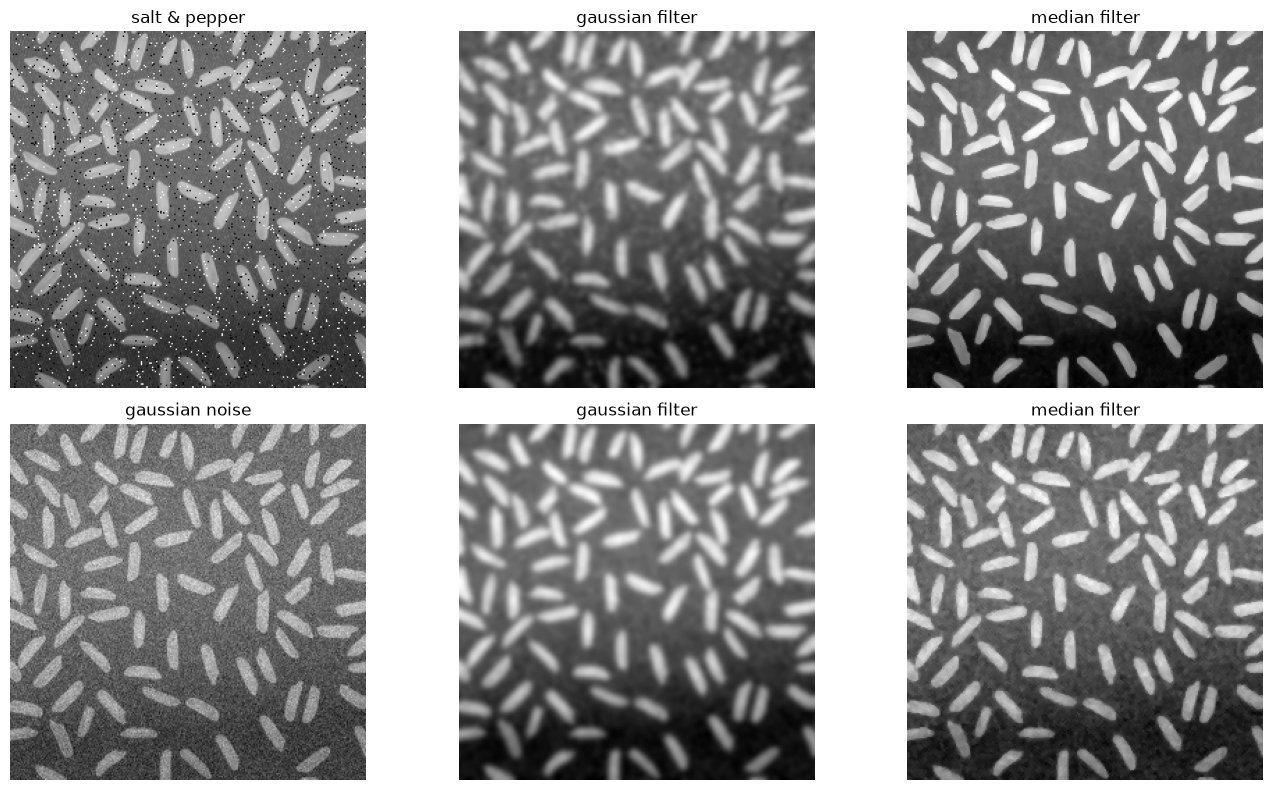

In [8]:
from skimage.filters import median
from skimage.morphology import disk as disk_fp

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

show(speckled, title="salt & pepper", ax=axes[0][0])
show(gaussian(speckled, sigma=2, preserve_range=True), title="gaussian filter", ax=axes[0][1])
show(median(speckled, disk_fp(2)), title="median filter", ax=axes[0][2])

show(grainy, title="gaussian noise", ax=axes[1][0])
show(gaussian(grainy, sigma=2, preserve_range=True), title="gaussian filter", ax=axes[1][1])
show(median(grainy, disk_fp(2)), title="median filter", ax=axes[1][2])

plt.tight_layout()
plt.show()

Look at the top row. The Gaussian filter *smears* each salt and pepper dot into a
gray blob: it averages, so one extreme pixel contaminates its whole
neighbourhood. The median filter removes them outright, because the median of a
neighbourhood simply ignores a single wild value.

On the bottom row, with ordinary grainy noise, both do a reasonable job.

**Rule of thumb**: median for isolated extreme pixels (dead pixels, cosmic rays,
salt and pepper), Gaussian for general graininess. A Gaussian also blurs edges,
which matters when a threshold comes next.

## 4. Morphology: cleaning up a binary image

The operations so far worked on intensities. **Morphological** operations work on
the *shape* of a binary image. The four used constantly are:

| operation | what it does | use it to |
|---|---|---|
| erosion | shave pixels off every edge | shrink objects, break thin bridges |
| dilation | add pixels to every edge | grow objects, close small gaps |
| opening | erode, then dilate | **remove small specks**, keep big shapes |
| closing | dilate, then erode | **fill small holes**, keep outlines |

Opening and closing are the useful pair, because each undoes its own size change
: an opening removes specks without shrinking what survives.

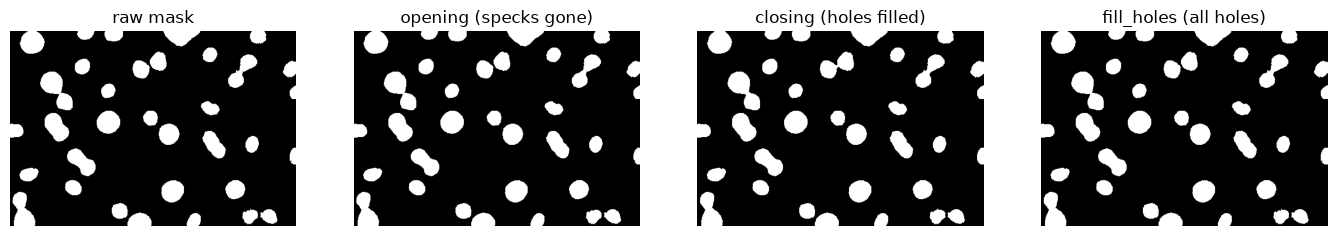

In [9]:
# scikit-image >= 0.26 uses `opening`/`closing` for both binary and greyscale
# images; the old `binary_opening`/`binary_closing` names are deprecated.
from skimage.morphology import opening, closing
from scipy.ndimage import binary_fill_holes

mask = nuclei > threshold_otsu(nuclei)

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
show(mask, title="raw mask", ax=axes[0])
show(opening(mask, disk(2)), title="opening (specks gone)", ax=axes[1])
show(closing(mask, disk(2)), title="closing (holes filled)", ax=axes[2])
show(binary_fill_holes(mask), title="fill_holes (all holes)", ax=axes[3])
plt.show()

## 5. Putting it together

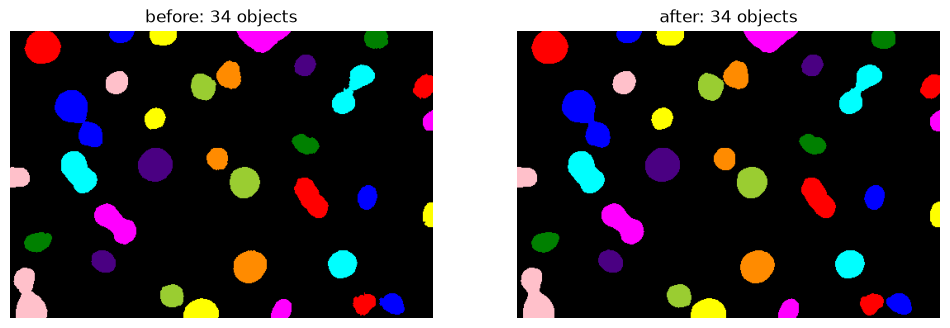

naive: 34  cleaned: 34  truth: 39


In [10]:
from skimage.morphology import remove_small_objects

# 1. smooth, so noise stops crossing the threshold
smoothed = gaussian(nuclei, sigma=1, preserve_range=True)

# 2. threshold the smoothed image
clean = smoothed > threshold_otsu(smoothed)

# 3. fill interior holes
clean = binary_fill_holes(clean)

# 4. drop anything too small to be a nucleus. On THIS image that removes
#    nothing - we checked the size distribution above - but it is cheap
#    insurance on a batch where some images are noisier than others.
#    NOTE: in scikit-image >= 0.26 this parameter is `max_size`, and it removes
#    objects smaller than OR EQUAL TO it. Older tutorials say `min_size`.
clean = remove_small_objects(clean, max_size=40)

cleaned = label(clean)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(label2rgb(naive, bg_label=0)); axes[0].set_axis_off()
axes[0].set_title(f"before: {naive.max()} objects")
axes[1].imshow(label2rgb(cleaned, bg_label=0)); axes[1].set_axis_off()
axes[1].set_title(f"after: {cleaned.max()} objects")
plt.show()

print("naive:", naive.max(), " cleaned:", cleaned.max(), " truth:", truth.max())

The count has not moved: 34 before, 34 after. Smoothing and hole-filling tidied
the shapes, and the size filter had nothing to remove: exactly as the size
distribution predicted.

That is worth seeing rather than being told. **A cleanup step is not automatically
an improvement**, and three of the four operations above earned nothing on this
particular image. The one problem this image actually has is still untouched.

The one that is left is a pair of nuclei that touch, and no amount of
threshold-tuning will separate them, as far as intensity is concerned they
really are one connected region. That needs a different idea.

## 6. Watershed: a second route from semantic to instance

The last notebook turned a semantic segmentation into an instance segmentation
with **connected component labeling**, where pixels that touch belong to the same
object, and showed exactly where that rule breaks: when two nuclei touch they
*are* one connected region, and get one label.

The pixels alone cannot say where to divide them. Their **shape** can. A pair of
touching nuclei is a wide blob with a narrow waist, and that waist is where the
boundary belongs.

The **watershed** exploits this. It treats the binary image as a landscape: imagine each
object as a hill; flood the landscape from the top of each hill, and where two
floods meet is the boundary between the objects.

Two things are needed: a landscape, and a starting point inside each object,
called a **seed**. The landscape comes from the **distance transform**, which replaces
every foreground pixel with its distance to the nearest background pixel. The
middle of an object is far from any edge, so it becomes a peak.

objects in this crop: 1  (there are really 2 nuclei)


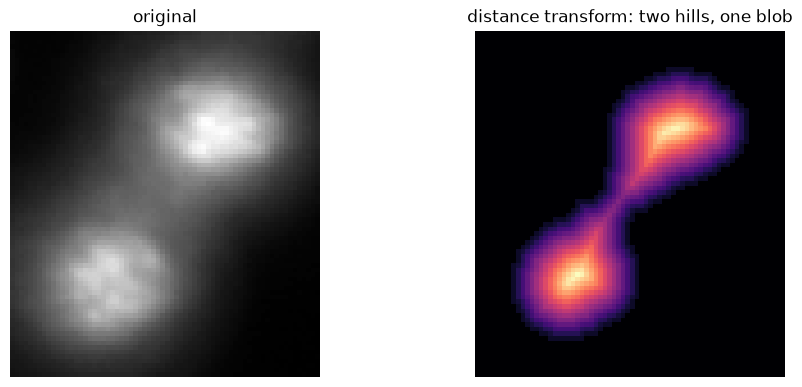

In [11]:
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

# Zoom in on a pair that merged.
region = (slice(33, 109), slice(382, 450))
sub_mask = clean[region]
print("objects in this crop:", label(sub_mask).max(), " (there are really 2 nuclei)")

distance = distance_transform_edt(sub_mask)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
show(nuclei[region], title="original", ax=axes[0])
show(distance, title="distance transform: two hills, one blob", cmap="magma", ax=axes[1])
plt.show()

### The obvious way to find the seeds

Two hills, so: find the local maxima and use those as seeds. `peak_local_max`
does exactly that, and needs nothing but the landscape.

In [12]:
def seeds_from_peaks(distance, mask):
    """Label every local maximum of `distance` as its own seed."""
    coordinates = peak_local_max(distance, labels=mask)
    seeds = np.zeros(mask.shape, dtype=int)
    for i, (row, column) in enumerate(coordinates, start=1):
        seeds[row, column] = i
    return seeds


seeds = seeds_from_peaks(distance, sub_mask)
result = watershed(-distance, seeds, mask=sub_mask)

print("seeds found:", seeds.max())
print("objects after watershed:", result.max(), " (we wanted 2)")

seeds found: 6
objects after watershed: 6  (we wanted 2)


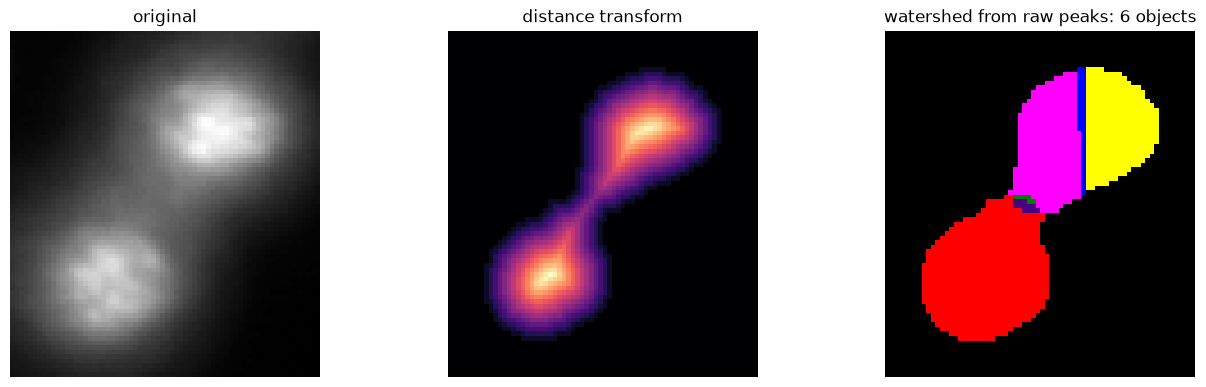

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
show(nuclei[region], title="original", ax=axes[0])
show(distance, title="distance transform", cmap="magma", ax=axes[1])
axes[2].imshow(label2rgb(result, bg_label=0)); axes[2].set_axis_off()
axes[2].set_title(f"watershed from raw peaks: {result.max()} objects")
plt.show()

Six objects where there are two. The watershed did nothing wrong: it was handed
six seeds and dutifully grew six regions.

The problem is the seeds. A distance transform is not smooth: every small
irregularity in the binary image boundary pushes the distance up or down a little, so a
single nucleus has several local maxima a pixel or two apart. `peak_local_max`
reports all of them.

**This is the failure mode to recognise**: when a watershed shatters objects into
fragments, the seeds are almost always the reason.

There are two straightforward ways to fix it.

### Fix 1: keep only the cores, by thresholding the distance

Rather than every local maximum, take the *regions* that lie deep inside the
object: pixels further than `t` from any edge. Each such core becomes one seed.

This gives the parameter a physical meaning. `distance > 5` says *"a seed is a
region whose centre is at least 5 pixels from the nearest boundary"*: that is,
only objects with a radius of about 5 px or more get their own seed.

In [14]:
for t in [4, 5, 6, 7]:
    seeds = label(distance > t)
    n = watershed(-distance, seeds, mask=sub_mask).max()
    print(f"distance > {t}  ->  {seeds.max()} seed(s)  ->  {n} object(s)")

distance > 4  ->  1 seed(s)  ->  1 object(s)
distance > 5  ->  2 seed(s)  ->  2 object(s)
distance > 6  ->  2 seed(s)  ->  2 object(s)
distance > 7  ->  2 seed(s)  ->  2 object(s)


At `t = 4` the two nuclei still share a single core and stay merged; from `t = 5`
upward the answer settles at two and stays there. **A parameter with a plateau
like that is one to trust**; if the answer changes every time it is nudged, the
result is not really saying anything.

### Fix 2: smooth the landscape, then find peaks

The other approach leaves the seed-finding alone and fixes the *landscape*. The
spurious maxima are small bumps, so blur them away before looking for peaks: 
the same trick as smoothing an image before thresholding it, applied to the
distance map instead.

Note that `peak_local_max` is still called with no tuning arguments. All the
control now sits in one Gaussian.

In [15]:
from skimage.filters import gaussian as gaussian_filter

for sigma in [1, 2, 3]:
    smoothed_distance = gaussian_filter(distance, sigma=sigma, preserve_range=True)
    seeds = seeds_from_peaks(smoothed_distance, sub_mask)
    n = watershed(-smoothed_distance, seeds, mask=sub_mask).max()
    print(f"sigma = {sigma}  ->  {seeds.max()} seed(s)  ->  {n} object(s)")

sigma = 1  ->  2 seed(s)  ->  2 object(s)
sigma = 2  ->  2 seed(s)  ->  2 object(s)
sigma = 3  ->  2 seed(s)  ->  2 object(s)


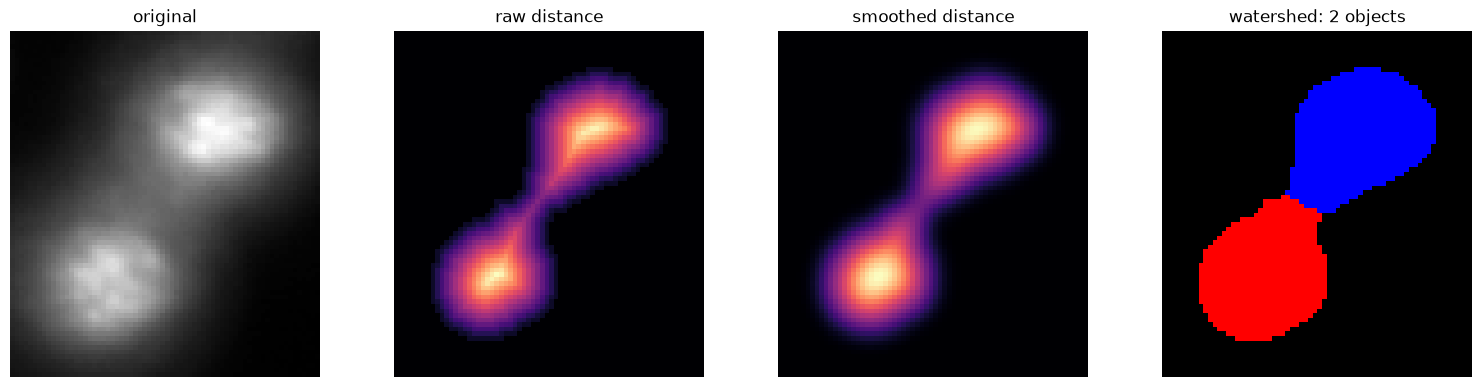

In [16]:
smoothed_distance = gaussian_filter(distance, sigma=2, preserve_range=True)
seeds = seeds_from_peaks(smoothed_distance, sub_mask)
split = watershed(-smoothed_distance, seeds, mask=sub_mask)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
show(nuclei[region], title="original", ax=axes[0])
show(distance, title="raw distance", cmap="magma", ax=axes[1])
show(smoothed_distance, title="smoothed distance", cmap="magma", ax=axes[2])
axes[3].imshow(label2rgb(split, bg_label=0)); axes[3].set_axis_off()
axes[3].set_title(f"watershed: {split.max()} objects")
plt.show()

Compare the two distance maps in the middle. The raw one is faintly lumpy; the
smoothed one has two clean summits. Same algorithm, same seed-finder, right
answer, because the landscape it was reading is no longer noisy.

Note the `-smoothed_distance` passed to `watershed`. The algorithm floods
*upward* from low ground, so the landscape is inverted: negating turns each
hilltop into the bottom of a basin.

Neither fix is more correct than the other. Thresholding gives a parameter in
units of object size, which is easy to reason about; smoothing keeps the
seed-finding parameter-free and copes better with objects of very different
sizes. Trying both, and seeing which is more stable, is the reliable way to
choose.

### On the whole image

In [17]:
distance_full = distance_transform_edt(clean)

raw_peaks = watershed(-distance_full, seeds_from_peaks(distance_full, clean), mask=clean)

threshold_seeded = watershed(-distance_full, label(distance_full > 5), mask=clean)

smoothed_full = gaussian_filter(distance_full, sigma=3, preserve_range=True)
smooth_seeded = watershed(-smoothed_full, seeds_from_peaks(smoothed_full, clean), mask=clean)

print(f"{'seeding':28s} {'objects':>8s}   (truth: {truth.max()})")
print("-" * 40)
print(f"{'raw peaks':28s} {raw_peaks.max():8d}")
print(f"{'distance > 5':28s} {threshold_seeded.max():8d}")
print(f"{'smoothed distance + peaks':28s} {smooth_seeded.max():8d}")
print(f"{'no watershed at all':28s} {cleaned.max():8d}")

seeding                       objects   (truth: 39)
----------------------------------------
raw peaks                          95
distance > 5                       36
smoothed distance + peaks          40
no watershed at all                34


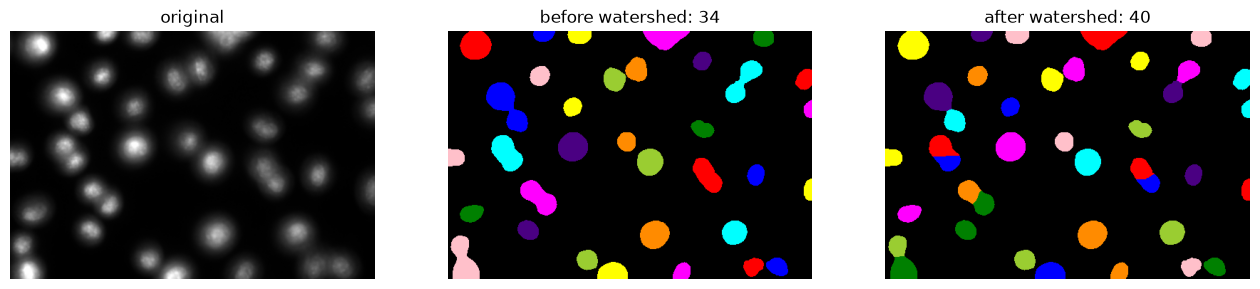

In [18]:
final = smooth_seeded

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
show(nuclei, title="original", ax=axes[0])
axes[1].imshow(label2rgb(cleaned, bg_label=0)); axes[1].set_axis_off()
axes[1].set_title(f"before watershed: {cleaned.max()}")
axes[2].imshow(label2rgb(final, bg_label=0)); axes[2].set_axis_off()
axes[2].set_title(f"after watershed: {final.max()}")
plt.show()

The raw peaks shatter the image into far more pieces than there are nuclei: the
same failure as on the crop, at scale. Both fixes bring it back to something
sensible, and the smoothed version lands closest to the annotation.

It did not find them all. Some nuclei overlap so much that even a smoothed
distance map shows a single hill, and no seeding rule separates those.

So we now have two ways from a semantic segmentation to an instance
segmentation, and they fail differently:

| route | rule | fails when |
|---|---|---|
| connected component labeling (`01` §7) | touching pixels are one object | objects touch each other |
| watershed (here) | split at the narrow waists | objects overlap heavily, or are irregular |

Three of our five cleanup steps did nothing on this image, the watershed did the
real work, and we are still a few nuclei short. Every result *looks*
plausible, the count moves in the right direction, and there is still no way to
say how good any of it actually is: a count of 40 could be 40 correct nuclei, or
34 correct ones plus 6 mistakes.

**Day 2 fixes that.** There are proper measures for comparing a
segmentation against a ground truth, and they show immediately what the count is
hiding.

## Recap

| problem | symptom | fix |
|---|---|---|
| uneven illumination | one threshold cannot fit everywhere | `white_tophat` |
| noise crossing the threshold | tiny speck "objects" | `gaussian` before thresholding |
| isolated extreme pixels | salt & pepper dots | `median` filter |
| holes inside objects | ring-shaped labels | `binary_fill_holes` |
| leftover specks | too many objects | `remove_small_objects`, after checking there are any |
| objects touching | two nuclei, one label | `watershed`, carefully seeded |

And the habit underneath all of it: **when a segmentation is bad, look at the
image before looking at the threshold.**

Plus the structural idea this notebook added: a threshold produces a *semantic*
segmentation, and there is more than one way to turn that into *instances*.
Connected components is the simple one; the watershed is the one that copes with
objects that touch.

Next: day 2, where guessing whether these results are good gives way to
start measuring it, and where a model learns the rules instead of us writing
them.